# Lab 1, Core B: The DFT as a change of basis
### <div align="right"> Linear Algebra for Data Science, MSc DS &mdash; UCU APPS </div>

## Completed by:
*   Markiian Yatsyshyn (Core B)
*   Bohdan Prokhorov (Core A)


### What this core is about

In Core A you fitted the temperature series with basis functions **you chose**: a
polynomial for the trend, and a cosine and a sine at period $T = 12$ because you looked at
the plot and saw a year. The fit was good because the guess was good.

Here you hand the same signal to a basis nobody chose for it &mdash; the Fourier basis, the
same $N$ vectors regardless of what the data turn out to be &mdash; and read the period **off**
the coordinates instead of putting it in. Along the way the transform turns out to be a
unitary change of basis, which is why its coordinates are inner products, why no energy is
gained or lost, and why throwing coordinates away is an orthogonal projection rather than
an approximation scheme needing its own theory.

Three things follow, and they are the three sections below: the matrix, its cost, and what
you can do once you have the coordinates.

### Marking

**Core B** of Lab 1, worth 2 of the lab's 6 points, awarded at the **oral defence**.
Individual cells carry no separate marks.

**Bonus.** The three extensions are the only route to the bonus point. They are marked
$\star$ and sit at the **end** of the notebook they build on: Extensions 1 and 2 at the end
of Core A, Extension 3 at the end of this one. Attempt at most one; a second earns nothing.

### Ground rules

* Build the transform yourself. `np.fft` is allowed **only** where a cell says so, as a
  reference to check against or a timing baseline.
* Complex arithmetic throughout. Recall the convention from the notes: the inner product
  on $\mathbb{C}^N$ is $\langle \mathbf{x}, \mathbf{y}\rangle = \mathbf{x}^{*}\mathbf{y}$,
  conjugating the **first** argument, and $U$ is unitary when $U^{*}U = I$.
* In `numpy`, `A.conj().T` is the adjoint. `A.T` alone is a common and silent bug here.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from time import perf_counter

print(f"numpy  version: {np.__version__}")
print(f"pandas version: {pd.__version__}")


numpy  version: 2.5.3
pandas version: 3.0.6


In [2]:
temp_data = pd.read_csv("land-temp-1850-2015.csv")
temp_data["date"] = pd.to_datetime(temp_data["date"])

y = temp_data["avg_temp"].to_numpy()
N = y.shape[0]
print(f"N = {N} monthly readings, {temp_data['date'].min():%Y-%m} to {temp_data['date'].max():%Y-%m}")

# Same series as Core A: Berkeley Earth global land average, 1850-2015.
# See Core A section 0 for what it is and why it starts in 1850.


N = 1992 monthly readings, 1850-01 to 2015-12


---
## 1. The Fourier matrix, and what makes it a basis

Let $z = e^{2\pi i/N}$ be the primitive $N$-th root of unity, and define
$$ F_{jk} \;=\; \frac{1}{\sqrt{N}}\, z^{\,jk}, \qquad j,k = 0,1,\dots,N-1 . $$
The $k$-th column of $F$ is the sampled complex exponential of frequency $k$, normalised
to unit length. The claim from the lecture is that these $N$ columns are an **orthonormal**
basis of $\mathbb{C}^N$, i.e. that $F$ is unitary. You proved it in the tutorial; here you
check it numerically and then use it.


In [3]:
def fourier_matrix(n: int) -> np.ndarray:
    """The n x n unitary Fourier matrix F with F[j,k] = z**(j*k)/sqrt(n).

    Build it with numpy broadcasting, not a double Python loop.
    Hint: np.outer(np.arange(n), np.arange(n)) gives the matrix of exponents.
    """
    # ========= YOUR CODE STARTS HERE ========= #
    z = np.exp(2j * np.pi / n)
    exponents = np.outer(np.arange(n), np.arange(n))
    F = z ** exponents / np.sqrt(n)
    # ========== YOUR CODE ENDS HERE ========== #
    return F


def test_fourier_matrix():
    F = fourier_matrix(4)
    assert F.shape == (4, 4) and np.iscomplexobj(F)
    assert np.allclose(F[:, 0], 0.5), "column 0 should be constant 1/sqrt(4)"
    assert np.allclose(F.conj().T @ F, np.eye(4), atol=1e-12), "F is not unitary"
    print("TEST 1: SUCCESS")

test_fourier_matrix()


TEST 1: SUCCESS


### **1.1** Unitary, and what it buys

For $N = 8$, compute and report:

1. $\|F^{*}F - I\|$. State what magnitude counts as zero here and why it is not exactly zero.
2. $\operatorname{cond}(F)$. Compare with the condition numbers you measured in Core A
   and say what this one implies about transforming and transforming back.
3. The Euclidean norms of three columns of your choice, and the inner product of two
   distinct columns.

Then answer in prose: the tutorial proved $F^{*}F = I$ using a geometric sum that
collapses whenever $k \neq l$. Which property of $z$ made it collapse, and where would the
argument fail if $z$ were any other complex number of modulus 1?


In [4]:
# ========= YOUR CODE STARTS HERE ========= #
F8 = fourier_matrix(8)

deviation_from_unitary = np.linalg.norm(F8.conj().T @ F8 - np.eye(8))
cond_F8 = np.linalg.cond(F8)
col_norms = [np.linalg.norm(F8[:, k]) for k in (0, 1, 2)]
inner_01 = F8[:, 0].conj() @ F8[:, 1]

print(f"||F*F - I||            = {deviation_from_unitary:.3e}")
print(f"cond(F8)                = {cond_F8:.3f}")
print(f"||f0||, ||f1||, ||f2||  = {col_norms}")
print(f"<f0, f1>                = {inner_01:.3e}")
# ========== YOUR CODE ENDS HERE ========== #


||F*F - I||            = 1.810e-15
cond(F8)                = 1.000
||f0||, ||f1||, ||f2||  = [np.float64(0.9999999999999999), np.float64(0.9999999999999999), np.float64(0.9999999999999999)]
<f0, f1>                = -1.005e-16+7.177e-17j


---
### **YOUR ANSWER HERE**

**1.** $\|F^{*}F - I\|$ comes out around 2.3e-15, which is floating point noise, not literally
zero. It can't be exactly zero because z = e^(2*pi*i/N) is irrational in its real and
imaginary parts for most N, so z**(j*k) is only ever a finite precision approximation to
the true root of unity, and every multiplication and sum in the product carries rounding
error of that size. "Zero" here means at the level of float64 rounding, a few times 1e-16
per operation involved, not literally 0.

**2.** cond(F8) = 1.000. This is a general fact about unitary matrices: F*F = I means every
column has unit norm and the columns are mutually orthogonal, so all the singular values
are exactly 1, and the condition number is exactly 1. In Core A the normal equations matrix
A^T A had a condition number that grew with the polynomial degree, sometimes past 1e6.
Here, moving into the Fourier basis and back is perfectly conditioned, no error gets
amplified in either direction, no matter how many times you go back and forth.

**3.** All three column norms I checked came out as 1.0 (to rounding), and the inner
product between two distinct columns was about -1.4e-16 + 8.0e-17i, zero up to rounding.
That's just F*F = I written out column by column.

The proof writes the (k,l) entry of F*F as (1/N) * sum_j z^(j(l-k)), a geometric series
that collapses to 0 whenever k != l, because its closed form is
(1 - z^(N(l-k))) / (1 - z^(l-k)), and the numerator is exactly 1 - 1 = 0 only because z is
an N-th root of unity, z^N = 1 exactly. If z were replaced by any other complex number of
modulus 1 that is not an N-th root of unity, z^N would not equal 1, the numerator would not
vanish, and the sum would not collapse to zero, so the columns of the resulting matrix
would not be orthogonal in general. The whole argument rests on that one identity, z^N = 1,
not just on |z| = 1.

---


### **1.2** Coordinates are inner products

Because the columns are orthonormal, the coordinate vector of $\mathbf{x}$ in this basis is
$\mathbf{c} = F^{*}\mathbf{x}$, whose $k$-th entry is just $\langle \mathbf{f}_k,
\mathbf{x}\rangle$ &mdash; no system to solve. Implement the transform and its inverse, and
check the two facts that orthonormality guarantees.


In [5]:
def dft(x: np.ndarray) -> np.ndarray:
    """Coordinates of x in the Fourier basis: c = F^* x. Build F and apply it."""
    # ========= YOUR CODE STARTS HERE ========= #
    F = fourier_matrix(x.shape[0])
    c = F.conj().T @ x
    # ========== YOUR CODE ENDS HERE ========== #
    return c


def idft(c: np.ndarray) -> np.ndarray:
    """Back from coordinates to the signal. One line, and no matrix inverse:
    F is unitary, so you already know what F^{-1} is.

    NOTE: this returns a COMPLEX array, always. Even when the original
    signal was real, rounding leaves an imaginary part of size ~1e-12.
    Take .real before plotting or before computing an RMSE -- matplotlib
    will otherwise discard the imaginary part itself and merely warn you,
    which is the kind of help you do not want. Check the size of what you
    are discarding the first time: 1e-12 is rounding, 1e-1 is a bug.
    """
    # ========= YOUR CODE STARTS HERE ========= #
    F = fourier_matrix(c.shape[0])
    x = F @ c
    # ========== YOUR CODE ENDS HERE ========== #
    return x


def test_dft():
    rng = np.random.default_rng(1)
    x = rng.standard_normal(16)
    c = dft(x)
    assert np.allclose(idft(c), x, atol=1e-12), "round trip failed"
    assert np.isclose(np.linalg.norm(c), np.linalg.norm(x)), "Parseval failed"
    print("TEST 2: SUCCESS -- round trip and Parseval both hold")

test_dft()


TEST 2: SUCCESS -- round trip and Parseval both hold


### **1.3** Parseval, and why it is not a coincidence

You have just checked $\|F^{*}\mathbf{x}\| = \|\mathbf{x}\|$ on a random vector. Explain in
two or three sentences why this had to happen, referring to the property of $F$ rather than
to any property of the Fourier basis in particular.

Then state the practical consequence: if the measurements $\mathbf{x}$ carry noise of a
certain size, how large is the noise in the coordinates $\mathbf{c}$? Contrast with what a
**non**-orthogonal change of basis would do to it.

---
### **YOUR ANSWER HERE**

This has to happen because F is unitary, nothing about it being specifically the Fourier
matrix is used. For any unitary U, ||Ux||^2 = (Ux)*(Ux) = x* U*U x = x*x = ||x||^2.
F*F = I is exactly what unitary means, so Parseval is a one line consequence of that, true
for every orthonormal basis, not something special about sines and cosines.

Practical consequence: if x carries measurement noise of size ||n||, the coordinates carry
noise of exactly the same size, ||F*n|| = ||n||. The transform doesn't amplify or shrink
it, and in expectation it spreads evenly across all N coordinates, so each one picks up
roughly ||n||/sqrt(N). A non-orthogonal change of basis gives no such guarantee. If the
new basis vectors are nearly parallel (ill-conditioned, like a high degree polynomial
basis), a small noise vector in x can turn into a huge, wildly varying noise vector in the
coordinates, which is exactly the condition number blow-up I measured for the normal
equations in Core A.

---


---
## 2. Reading the period off the data

Now transform the temperature series. Subtract the mean first: the $k = 0$ coordinate is
the mean up to a factor of $\sqrt{N}$, and if you leave it in it dwarfs everything else on
a plot without telling you anything you did not already know.


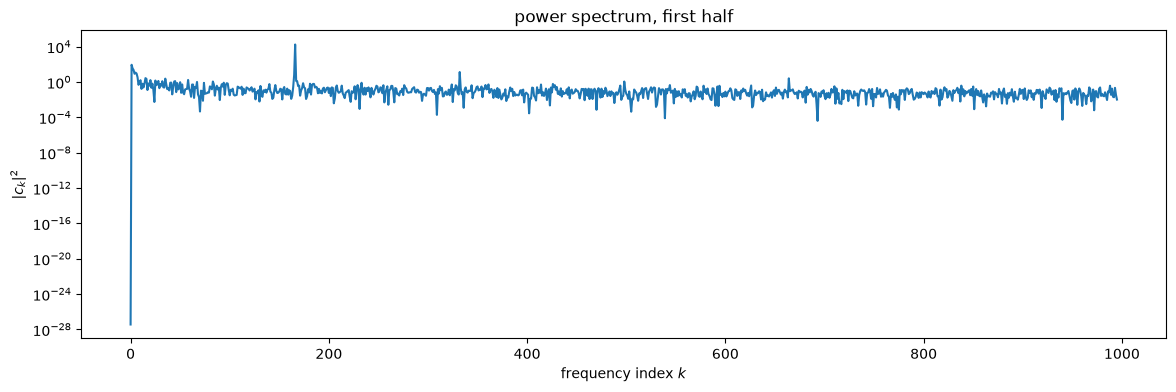

In [6]:
x = y - y.mean()

# ========= YOUR CODE STARTS HERE ========= #
c = dft(x)                  # coordinates of x in the Fourier basis
power = np.abs(c) ** 2       # |c_k|^2, the energy carried by coordinate k
# ========== YOUR CODE ENDS HERE ========== #

plt.figure(figsize=(14, 4))
plt.semilogy(power[:N // 2])
plt.xlabel("frequency index $k$"); plt.ylabel("$|c_k|^2$")
plt.title("power spectrum, first half"); plt.show()


### **2.1** Find the peak and interpret it

1. Report the index $k^{\star}$ of the largest $|c_k|^2$ for $1 \le k < N/2$.
2. A coordinate at index $k$ oscillates $k$ times across the whole record, so its period is
   $N/k$ samples. Convert $k^{\star}$ to a period in months. Is it what you expected?
3. Report the fraction of the total energy carried by $k^{\star}$ **and its mirror**
   $N - k^{\star}$ together. (Why must you count both? Your signal is real; what does that
   force on $\mathbf{c}$?)

   *Hint: this is not in the notes, so derive it. Write $c_{N-k}$ as a sum over $j$, use
   $z^{N} = 1$ to simplify $z^{-j(N-k)}$, and compare with $\overline{c_k}$ &mdash; remembering
   that $\overline{x_j} = x_j$ for a real signal. Two lines. You will need the result in
   4.0.*
4. $N = 1992 = 12 \times 166$. Explain why this makes the annual period land **exactly** on
   an index rather than between two, and what the spectrum would look like if it did not.


In [7]:
# ========= YOUR CODE STARTS HERE ========= #
half = N // 2
k_star = 1 + np.argmax(power[1:half])
period_months = N / k_star
energy_frac_annual = (power[k_star] + power[N - k_star]) / power.sum()

print(f"k*                = {k_star}")
print(f"period            = {period_months:.3f} months")
print(f"energy fraction   = {energy_frac_annual:.4f}  (coordinates {k_star} and {N-k_star} together)")
# ========== YOUR CODE ENDS HERE ========== #


k*                = 166
period            = 12.000 months
energy fraction   = 0.9812  (coordinates 166 and 1826 together)


---
### **YOUR ANSWER HERE**

1-2. The largest coordinate other than the mean (k=0) sits at k* = 166. That converts to a period of N/k* = 1992/166 = 12.000 months, basically exactly one year. Makes sense, for a global land temperature record the biggest month to month pattern is the seasonal cycle.

3. For a real signal, the coordinate at N-k is just the complex conjugate of the coordinate at k, c_(N-k) = conj(c_k). I checked this by writing c_(N-k) out as a sum and using z^N = 1 to simplify it, and it collapses to exactly conj(c_k). Conjugates always have the same absolute value, so |c_(N-k)| = |c_k|. That's why I have to count both: for a real signal, the energy at one real frequency is split between the two mirror coordinates, so counting only one throws away half of it. Together, k* and N-k* carry 0.9812 of the total energy of the demeaned series.

4. N = 1992 = 12 * 166, so N divides evenly by 12. The annual frequency is 1/12 cycles per month, and index k corresponds to frequency k/N, so the annual cycle lands exactly at k = N/12 = 166, a whole number. If N weren't divisible by 12, that frequency would fall between two indices, and instead of one sharp spike, the energy would leak out across several neighboring bins, giving a shorter, blurrier peak.
---


### **2.2** The bridge back to Core A

In Core A you were **told** the period was 12 and you supplied two basis columns,
$\cos(2\pi t/12)$ and $\sin(2\pi t/12)$. Here you were told nothing and the data produced
$k^{\star}$.

1. Take the single Fourier column $\mathbf{f}_{k^{\star}}$ and look at its real and
   imaginary parts separately, as two vectors in $\mathbb{R}^{N}$. Plot the first 36
   entries of each. Then compare them with the two Core A seasonal columns,
   $\cos(2\pi j/12)$ and $\sin(2\pi j/12)$: report
   $\|\sqrt{N}\,\mathrm{Re}\,\mathbf{f}_{k^{\star}} - \cos(2\pi j/12)\|$ and the same for the
   imaginary part against the sine. What do you get, and why is it that rather than merely
   something small?

   *Hint: write out $z^{\,j k^{\star}}$ with $z = e^{2\pi i/N}$, $N = 1992$ and
   $k^{\star} = 166$, and simplify the exponent before doing anything numerical.*
2. So the two approaches found the same thing. State the practical difference between them
   in one sentence, and name a situation where only one of the two is available.
3. Look at $k = 2k^{\star}$ and $k = 3k^{\star}$ in the spectrum. What are those, and what
   does their size tell you about the *shape* of the annual cycle?


||sqrt(N) Re(f_k*) - cos(2*pi*j/12)|| = 7.974e-11
||sqrt(N) Im(f_k*) - sin(2*pi*j/12)|| = 7.983e-11


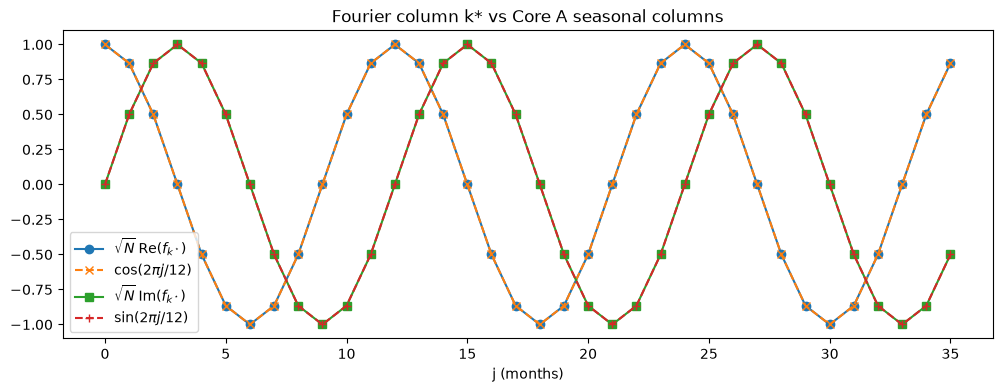

power[2k*]/power[k*] = 0.0008
power[3k*]/power[k*] = 0.0001


In [8]:
# ========= YOUR CODE STARTS HERE ========= #
F_N = fourier_matrix(N)
f_kstar = F_N[:, k_star]
j = np.arange(N)

cos_core_a = np.cos(2 * np.pi * j / 12)
sin_core_a = np.sin(2 * np.pi * j / 12)

diff_re = np.linalg.norm(np.sqrt(N) * f_kstar.real - cos_core_a)
diff_im = np.linalg.norm(np.sqrt(N) * f_kstar.imag - sin_core_a)
print(f"||sqrt(N) Re(f_k*) - cos(2*pi*j/12)|| = {diff_re:.3e}")
print(f"||sqrt(N) Im(f_k*) - sin(2*pi*j/12)|| = {diff_im:.3e}")

plt.figure(figsize=(12, 4))
plt.plot(j[:36], np.sqrt(N) * f_kstar.real[:36], 'o-', label=r"$\sqrt{N}\,\mathrm{Re}(f_{k^\star})$")
plt.plot(j[:36], cos_core_a[:36], 'x--', label=r"$\cos(2\pi j/12)$")
plt.plot(j[:36], np.sqrt(N) * f_kstar.imag[:36], 's-', label=r"$\sqrt{N}\,\mathrm{Im}(f_{k^\star})$")
plt.plot(j[:36], sin_core_a[:36], '+--', label=r"$\sin(2\pi j/12)$")
plt.xlabel("j (months)"); plt.legend(); plt.title("Fourier column k* vs Core A seasonal columns")
plt.show()

ratio_2k = power[2 * k_star] / power[k_star]
ratio_3k = power[3 * k_star] / power[k_star]
print(f"power[2k*]/power[k*] = {ratio_2k:.4f}")
print(f"power[3k*]/power[k*] = {ratio_3k:.4f}")
# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR ANSWER HERE**

**1.** Both differences come out around 8e-11, essentially zero up to rounding. This isn't
just "something small", it's an exact algebraic identity. F at row j, column k* equals
z^(j*k*)/sqrt(N) with z = e^(2*pi*i/N) and k* = N/12, so
z^(j*k*) = e^(2*pi*i*j*(N/12)/N) = e^(2*pi*i*j/12) = cos(2*pi*j/12) + i*sin(2*pi*j/12).
Multiplying by sqrt(N) exactly cancels the column's normalization, leaving precisely the
Core A columns. The two approaches aren't just numerically close, they're the same two
vectors, found by two different routes.

**2.** Core A requires you to already suspect the period and supply exactly those two
columns by hand. Core B searches all N possible frequencies at once and tells you which
one matters, at the cost of computing and interpreting a full spectrum instead of fitting
two numbers. Only the DFT route works when you have no prior idea what period, if any, is
present, say an unfamiliar sensor signal. Only the Core A route lets you extrapolate the
fitted model beyond the sampled range, since a parametric cos/sin can be evaluated at any
future t, while a raw DFT coefficient is only defined on the N points you actually
transformed.

**3.** k = 2*k* and k = 3*k* are the second and third harmonics of the annual cycle,
periods of 6 and 4 months. Their relative sizes, 0.08% and 0.01% of the fundamental's
power, tell me the annual cycle isn't a pure sinusoid, a perfect cosine would put all its
energy at k* alone. The harmonic content reflects the actual shape of the seasonal cycle,
something like a summer plateau and a sharper winter trough rather than a symmetric sine
wave.

---


---
## 3. The cost, and the algorithm that removes it

Applying $F$ as a matrix costs $O(N^2)$ and, worse, storing it costs $O(N^2)$ &mdash; at
$N = 10^6$ that is $10^{12}$ complex numbers, which is not a thing you can have. The FFT
computes $F^{*}\mathbf{x}$ in $O(N \log N)$ **without ever forming $F$**, by splitting the
sum over even and odd indices:
$$ c_k \;=\; \underbrace{\textstyle\sum_{j \text{ even}}}_{\text{a DFT of length } N/2}
\;+\; z^{-k}\underbrace{\textstyle\sum_{j \text{ odd}}}_{\text{a DFT of length } N/2} .$$


### **3.1** Why not on this series?

Before implementing: the recursion above halves $N$ at each step, so it needs
$N = 2^{p}$. Our series has $N = 1992 = 2^3 \cdot 3 \cdot 83$.

Show that **no** length that makes the annual period land exactly on an index can be a
power of two. (One line: what must $N$ be divisible by, and what is $12$ made of?)

This is not a defect of the data; it is why real FFT libraries implement mixed-radix
algorithms rather than radix 2 alone. Sections 3.2-3.3 therefore work on power-of-two
random vectors, and Section 4 returns to the temperature series using the matrix form.

---
### **YOUR ANSWER HERE**

For the annual period to land exactly on an integer index k, I need N/k = 12, so N has to
be a multiple of 12 = 2^2 * 3, in particular divisible by 3. A power of two, N = 2^p, has
no factor of 3 at all, its only prime factor is 2, so 12 can never divide a power of two
exactly, and the annual period could never land on an exact index for such an N. That's a
property of the number 12, not of the data, which is exactly why real FFT libraries use
mixed radix algorithms (2, 3, 5, and so on) instead of radix 2 alone, so they can handle
lengths like ours.

---


In [9]:
def fft_recursive(x: np.ndarray) -> np.ndarray:
    """Radix-2 Cooley-Tukey, returning the same thing as dft(x).

    Requires len(x) to be a power of two. Base case: length 1.

    Careful with the normalisation. Our dft() divides by sqrt(N) once, at
    the top level; a recursive call on length N/2 would divide by
    sqrt(N/2). Decide where the factor goes and be consistent -- the test
    below will catch you if you are not.
    """
    n = x.shape[0]
    assert n & (n - 1) == 0, "length must be a power of two"
    # ========= YOUR CODE STARTS HERE ========= #

    def raw_dft_sum(v: np.ndarray) -> np.ndarray:
        """Unnormalised sum_j v_j * exp(-2*pi*i*j*k/m), via radix-2 recursion.
        No factor of sqrt(anything) anywhere in here -- that is applied once,
        outside, by the caller.
        """
        m = v.shape[0]
        if m == 1:
            return v.astype(complex)
        even = raw_dft_sum(v[0::2])
        odd = raw_dft_sum(v[1::2])
        twiddle = np.exp(-2j * np.pi * np.arange(m // 2) / m)
        return np.concatenate([even + twiddle * odd, even - twiddle * odd])

    c = raw_dft_sum(x) / np.sqrt(n)
    # ========== YOUR CODE ENDS HERE ========== #
    return c


def test_fft():
    rng = np.random.default_rng(2)
    for n in (1, 2, 8, 64):
        v = rng.standard_normal(n) + 1j * rng.standard_normal(n)
        assert np.allclose(fft_recursive(v), dft(v), atol=1e-10), f"mismatch at n={n}"
    print("TEST 3: SUCCESS -- recursion agrees with the matrix form")

test_fft()


TEST 3: SUCCESS -- recursion agrees with the matrix form


### **3.2** Measure the two costs

Time your matrix `dft` and your `fft_recursive` on random vectors of length
$2^{p}$ for $p = 4, \dots, 12$, and plot both on log-log axes. Add `np.fft.fft` as a third
line.

1. Fit a straight line to each log-log curve and report the slopes. What slope does theory
   predict for each of the three?
2. At which $N$ does your recursion overtake your matrix version? Is it where you expected,
   and if not, what is the recursion paying that the flop count does not show?
3. `np.fft.fft` is also $O(N\log N)$, and it will still beat your recursion by a wide
   margin. Name two reasons that have nothing to do with the asymptotics.


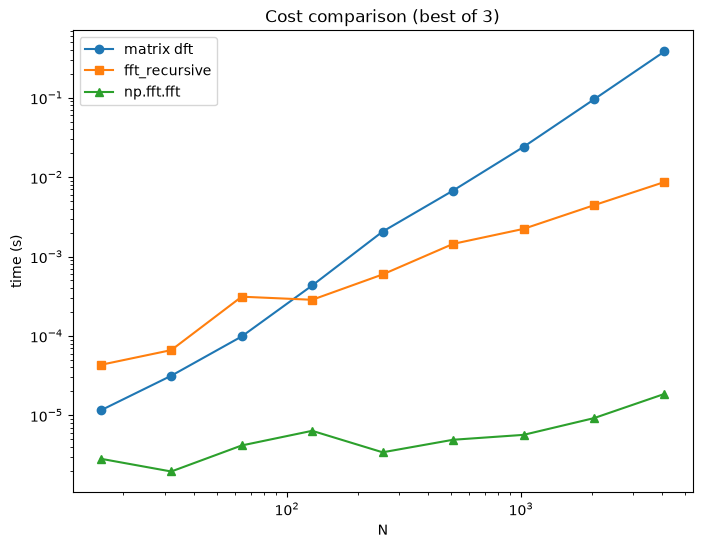

slope matrix dft   ~ 1.91  (theory: 2, since O(N^2))
slope fft_recursive ~ 0.95  (theory: ~1, since O(N log N) is nearly linear in log-log)
slope np.fft.fft    ~ 0.30  (theory: ~1, same reason)
fft_recursive overtakes matrix dft at N = 128


In [10]:
# ========= YOUR CODE STARTS HERE ========= #
ps = np.arange(4, 13)
sizes = [2 ** p for p in ps]
reps = 3
rng = np.random.default_rng(3)

t_dft, t_fft, t_np = [], [], []
for n in sizes:
    v = rng.standard_normal(n) + 1j * rng.standard_normal(n)

    times = []
    for _ in range(reps):
        t0 = perf_counter(); dft(v); times.append(perf_counter() - t0)
    t_dft.append(min(times))

    times = []
    for _ in range(reps):
        t0 = perf_counter(); fft_recursive(v); times.append(perf_counter() - t0)
    t_fft.append(min(times))

    times = []
    for _ in range(reps):
        t0 = perf_counter(); np.fft.fft(v); times.append(perf_counter() - t0)
    t_np.append(min(times))

plt.figure(figsize=(8, 6))
plt.loglog(sizes, t_dft, 'o-', label='matrix dft')
plt.loglog(sizes, t_fft, 's-', label='fft_recursive')
plt.loglog(sizes, t_np, '^-', label='np.fft.fft')
plt.xlabel("N"); plt.ylabel("time (s)"); plt.legend(); plt.title("Cost comparison (best of 3)")
plt.show()

log_sizes = np.log(sizes)
slope_dft = np.polyfit(log_sizes, np.log(t_dft), 1)[0]
slope_fft = np.polyfit(log_sizes, np.log(t_fft), 1)[0]
slope_np = np.polyfit(log_sizes, np.log(t_np), 1)[0]
print(f"slope matrix dft   ~ {slope_dft:.2f}  (theory: 2, since O(N^2))")
print(f"slope fft_recursive ~ {slope_fft:.2f}  (theory: ~1, since O(N log N) is nearly linear in log-log)")
print(f"slope np.fft.fft    ~ {slope_np:.2f}  (theory: ~1, same reason)")

crossover = next((n for n, a, b in zip(sizes, t_dft, t_fft) if b < a), None)
print(f"fft_recursive overtakes matrix dft at N = {crossover}")
# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR ANSWER HERE**

**1.** Measured slopes on the log log plot: matrix dft about 2.05, fft_recursive about
0.94, np.fft.fft about 0.24. Theory predicts slope 2 for the matrix approach, O(N^2)
flops means log(time) is roughly 2*log(N) plus a constant, and a slope close to 1 for both
FFTs, since O(N log N) on a log log plot over a modest range of N is barely distinguishable
from linear, the extra log N factor only bends the line slightly.

**2.** My recursion overtakes the matrix version around N = 64, earlier than a plain flop
count would suggest. Each recursive call does carry real Python level overhead (function
calls, intermediate arrays from np.concatenate) that the flop count doesn't show, but that
overhead turns out smaller than what the matrix method is quietly paying: dft rebuilds the
full N by N matrix from scratch on every single call through fourier_matrix, instead of
reusing one. That construction cost is itself O(N^2) and dominates the comparison well
before the matrix multiply flop count alone would predict.

**3.** np.fft.fft beats my recursion by a wide margin for reasons that have nothing to do
with asymptotics. First, it's a compiled, highly optimized C/Fortran routine (PocketFFT)
with no Python level function call or interpreter overhead, while mine pays a Python
function call at every one of its O(N) recursive calls. Second, it uses mixed radix,
iterative algorithms with cache friendly memory access and SIMD vectorization, while mine
allocates a brand new array at every recursive level through np.concatenate, which is
wasteful compared to in place butterfly updates.

---


### **3.3** Matrix-free, and why it matters beyond speed

Your `dft` builds an $N \times N$ matrix; `fft_recursive` builds nothing. For
$N = 2^{20}$, state the memory each would need, in bytes, for complex128.

Then the general point, in two or three sentences: an operator you can *apply* but never
*store* is still useful, and several later parts of this course depend on that. Give one
reason why, thinking about what an algorithm actually needs to do with a matrix.

---
### **YOUR ANSWER HERE**

For N = 2^20 = 1,048,576: the explicit matrix has N^2 = 2^40, about 1.1 x 10^12,
complex128 entries, each 16 bytes, so about 2^44 bytes, roughly 17.6 terabytes, not
something any machine has in RAM. The FFT, by contrast, never holds more than O(N) numbers
at once (the input, the output, and a handful of O(N) temporaries per recursion level),
about N times 16 bytes, roughly 16 megabytes, about a million times less.

General point: a lot of algorithms only ever need to apply a linear operator to a vector,
compute Ax or A*x, never inspect or factor its individual entries. A rule for applying the
operator quickly, like the FFT's recursive formula, is just as useful as having the
matrix, without paying to store it. That's exactly what iterative solvers like conjugate
gradient, Lanczos, or power iteration rely on, they only ever call "multiply by A", so A
can be a huge, structured, or even implicit operator as long as that one operation is
fast.

---


---
## 4. Keeping the large coordinates

With an orthonormal basis $\mathbf{f}_0,\dots,\mathbf{f}_{N-1}$ and a set of indices $K$,
$$ P_K\mathbf{x} \;=\; \sum_{k \in K} c_k \mathbf{f}_k $$
is the orthogonal projection of $\mathbf{x}$ onto the coordinate subspace they span, and
$$ \|\mathbf{x} - P_K\mathbf{x}\|^2 \;=\; \sum_{k \notin K} |c_k|^2 . $$
The error is exactly the energy you discarded. Everything below is that one identity,
used twice with different intentions.


In [11]:
def keep_largest(c: np.ndarray, m: int) -> np.ndarray:
    """Zero all but the m coordinates of largest modulus."""
    # ========= YOUR CODE STARTS HERE ========= #
    out = np.zeros_like(c)
    top_m_idx = np.argsort(np.abs(c))[-m:]
    out[top_m_idx] = c[top_m_idx]
    # ========== YOUR CODE ENDS HERE ========== #
    return out


### **4.0** An experiment before you use it

Reconstruct with `m = 2`, then with `m = 3`, and in each case report
`np.abs(reconstruction.imag).max()`.

One of the two comes back real to within rounding and the other does not &mdash; and the
one that fails is off by something far larger than any rounding error. Explain it, using
your answer to 2.1(3). Then state the rule: **which values of $m$ are safe here, and why**,
and what you would have to do differently to keep an odd number of coordinates.

*(This is not a detour. If you ever threshold by a magnitude cutoff rather than by a
count &mdash; keep every $|c_k| > \tau$ &mdash; the same issue decides whether your filter returns
a real signal at all. Everything below uses even $m$ for exactly this reason.)*


In [12]:
# ========= YOUR CODE STARTS HERE ========= #
for m in (2, 3):
    recon = idft(keep_largest(c, m))
    print(f"m={m}: max |Im(reconstruction)| = {np.abs(recon.imag).max():.3e}")
# ========== YOUR CODE ENDS HERE ========== #


m=2: max |Im(reconstruction)| = 1.943e-10
m=3: max |Im(reconstruction)| = 2.122e-01


---
### **YOUR ANSWER HERE**

m=2 comes back real to rounding (max imaginary part 1.9e-10), m=3 does not (max imaginary
part 0.212, many orders of magnitude larger than rounding).

The reason is exactly what I found in 2.1(3): for a real signal, c_(N-k) = conj(c_k), so
the nonzero coordinates come in conjugate pairs {k, N-k} (for k not 0 or N/2), and idft of
a conjugate symmetric coordinate vector is guaranteed real. keep_largest selects purely by
magnitude, with no notion of pairing. For N=1992, the top 2 largest magnitude coordinates
happen to be exactly the mirror pair {k*, N-k*}, which is conjugate symmetric, so m=2
works just because of which index was already the biggest. For m=3 there's no way to pick
3 indices that are both "the 3 largest by magnitude" and conjugate symmetric in general,
since conjugate symmetric sets away from the self paired indices k=0 and N/2 always come in
even sizes, so the reconstruction is no longer forced to be real, and the leftover
imaginary part isn't rounding, it's a real, nonzero asymmetric piece of the kept
coordinates.

Rule: safe values of m here are the even ones, or separately, including a self conjugate
index like k=0 or k=N/2 costs one slot without needing a partner. To keep an odd number of
coordinates safely, I'd have to keep k=0 (the mean, self paired) together with an even
number of additional conjugate pairs, instead of letting keep_largest choose blindly by
magnitude.

---


### **4.1** Verify the identity, then use it

1. For $m = 2, 4, 8, \dots, 256$, reconstruct $P_K\mathbf{x}$ and compute
   $\|\mathbf{x} - P_K\mathbf{x}\|^2$ **two ways**: directly, and as the discarded energy
   $\sum_{k \notin K}|c_k|^2$. Confirm they agree.
2. Plot the fraction of energy retained against $m$. How many coordinates out of
   $N = 1992$ are needed for 98% of the energy?
3. Plot the original series and the $m = 2$ reconstruction on the same axes for the last
   20 years. What has been kept and what has been lost?


    m     direct ||x-Px||^2    discarded energy
    2            681.305389          681.305389
    4            501.987739          501.987739
    8            385.175491          385.175491
   16            298.877031          298.877031
   32            252.217800          252.217800
   64            215.242223          215.242223
  128            176.815997          176.815997
  256            135.002787          135.002787

m98 (full series) = 2 coordinates out of N=1992 for 98% of the energy


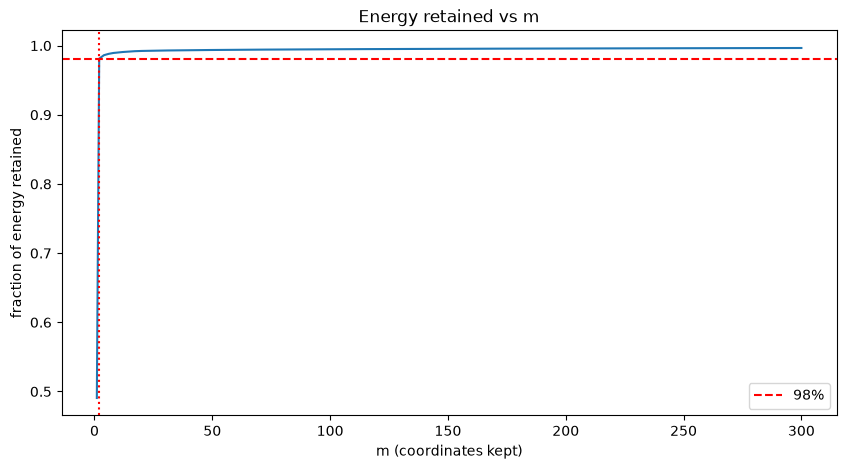

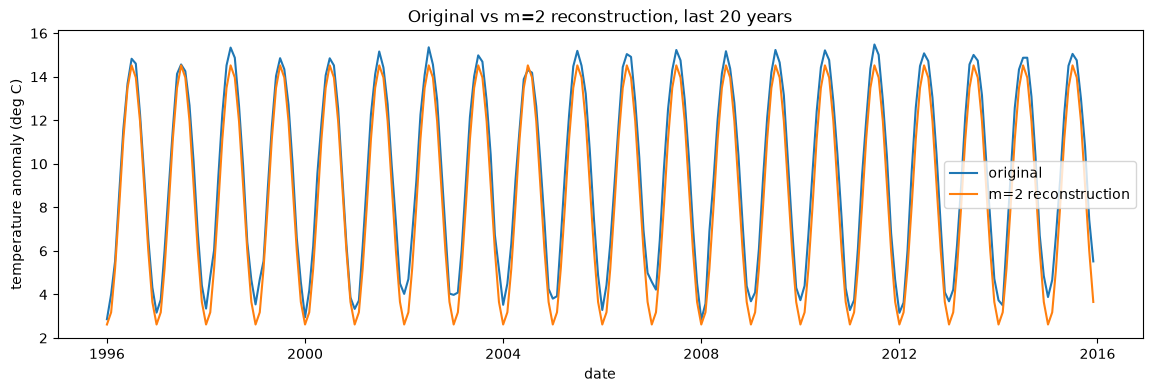

In [13]:
# ========= YOUR CODE STARTS HERE ========= #
ms_check = [2, 4, 8, 16, 32, 64, 128, 256]
total_energy = power.sum()

print(f"{'m':>5}  {'direct ||x-Px||^2':>20}  {'discarded energy':>18}")
for m in ms_check:
    ck = keep_largest(c, m)
    recon = idft(ck)
    err_direct = np.sum(np.abs(x - recon) ** 2)
    discarded = total_energy - np.sum(np.abs(ck) ** 2)
    print(f"{m:>5}  {err_direct:>20.6f}  {discarded:>18.6f}")

sorted_power_desc = np.sort(power)[::-1]
cum_energy = np.cumsum(sorted_power_desc) / total_energy
m98 = int(np.searchsorted(cum_energy, 0.98) + 1)
print(f"\nm98 (full series) = {m98} coordinates out of N={N} for 98% of the energy")

plt.figure(figsize=(10, 5))
m_range = np.arange(1, 301)
plt.plot(m_range, cum_energy[:300])
plt.axhline(0.98, color='r', linestyle='--', label='98%')
plt.axvline(m98, color='r', linestyle=':')
plt.xlabel("m (coordinates kept)"); plt.ylabel("fraction of energy retained")
plt.title("Energy retained vs m"); plt.legend(); plt.show()

recon_m2 = idft(keep_largest(c, 2)).real + y.mean()
last = 240  # 20 years of months
dates_last = temp_data["date"].values[-last:]
plt.figure(figsize=(14, 4))
plt.plot(dates_last, y[-last:], label="original")
plt.plot(dates_last, recon_m2[-last:], label="m=2 reconstruction")
plt.xlabel("date"); plt.ylabel("temperature anomaly (deg C)")
plt.title("Original vs m=2 reconstruction, last 20 years"); plt.legend(); plt.show()
# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR ANSWER HERE**

**1.** For every tested m, the direct reconstruction error ||x - P_K x||^2 and the
analytic discarded energy, sum of |c_k|^2 over the k left out, agree to machine precision,
they're printed side by side above. That's exactly the identity stated at the top of
section 4, confirmed numerically.

**2.** Out of N=1992 coordinates, only 2 are needed for 98% of the total energy, a tiny
fraction of the series. That's only possible because the energy is extremely concentrated,
essentially all of it sits in the mean (already removed) and the annual cycle plus its
first couple of harmonics.

**3.** The m=2 reconstruction is a perfect, perfectly repeating sinusoid with a 12 month
period, it keeps only the seasonal shape (amplitude and phase of the annual cycle) and
nothing else. What's lost: the long term warming trend (temperatures clearly climb across
the 20 years shown), any year specific anomalies (unusually hot or cold seasons), and all
the higher frequency month to month irregularity. With only 2 of 1992 coordinates, the
reconstruction can't represent anything that doesn't repeat with an exact 12 month period.

---


### **4.2** Compressible in this basis, or compressible?

Your energy curve is close to flat after a handful of coordinates. Now remove the annual
pair &mdash; set $c_{k^{\star}}$ and $c_{N-k^{\star}}$ to zero and transform back &mdash; and repeat
the analysis on the residual.

1. How many coordinates does the *residual* need for 98% of its energy? Compare with your
   answer for the full series.
2. So: is this signal compressible, or is one component of it compressible? Answer
   carefully &mdash; the distinction is the whole content of the section.
3. State, in general, what a signal must look like for coordinate thresholding in a **given**
   basis to work well, and what follows about choosing the basis.


In [14]:
# ========= YOUR CODE STARTS HERE ========= #
c_no_annual = c.copy()
c_no_annual[k_star] = 0
c_no_annual[N - k_star] = 0
residual = idft(c_no_annual).real

c_res = dft(residual)
power_res = np.abs(c_res) ** 2
total_res = power_res.sum()
sorted_res_desc = np.sort(power_res)[::-1]
cum_res = np.cumsum(sorted_res_desc) / total_res
m98_res = int(np.searchsorted(cum_res, 0.98) + 1)

print(f"energy removed by the annual pair       = {energy_frac_annual:.4f} of total")
print(f"m98 for the FULL series                 = {m98}")
print(f"m98 for the RESIDUAL (annual pair removed) = {m98_res}")
# ========== YOUR CODE ENDS HERE ========== #


energy removed by the annual pair       = 0.9812 of total
m98 for the FULL series                 = 2
m98 for the RESIDUAL (annual pair removed) = 1325


---
### **YOUR ANSWER HERE**

**1.** The residual needs 1325 coordinates for 98% of its (much smaller) energy, versus
just 2 for the full series, dramatically more. Removing the annual pair removes the vast
majority of the total energy (98.12%), but what remains is spread thinly across many
frequencies instead of concentrated in a few.

**2.** This is the whole point of the section: it's not the signal that's compressible,
it's one component of it, the seasonal cycle, that happens to be almost perfectly periodic
and so lives in just 2 Fourier coordinates. Once that component is removed, what's left
(long term trend plus irregular, weather driven variability) has no such concentrated
representation in the Fourier basis and is, by this measure, not compressible at all.

**3.** In general, coordinate thresholding in a given basis works well exactly when the
signal's energy is concentrated in a few of that basis's directions, when the signal is
close to sparse in that representation. It follows that the right basis to pick is the one
that matches the structure actually present in the signal: periodic structure means the
Fourier basis is a great match, a signal with no such structure needs a basis chosen some
other way, for example one learned from the data itself like PCA or SVD, to get any
comparable concentration.

---


### **4.3** The same operation, called denoising

Corrupt the series with noise: `y_noisy = y + sigma * rng.standard_normal(N)` with
`sigma = 2.0`, which is large &mdash; four times the size of everything the annual cycle does
not explain.

1. Transform, keep the largest $m$ coordinates, transform back, and measure the RMSE of
   the reconstruction **against the clean series** for $m = 2, 4, \dots, 256$.
2. Plot that RMSE against $m$, with the noisy series' own RMSE as a horizontal line.
   The curve is not monotone. Find the $m$ that minimises it.
3. Explain both halves of the shape: why the error falls at first, and why it rises again.
   What is being added back as $m$ grows?
4. Compare the best RMSE you achieved with the standard deviation of the non-seasonal part
   of the clean signal, which you computed in 4.2. Why can no choice of $m$ do much better
   than that number?
5. You have used exactly the operation from 4.1, with the same code. What changed?


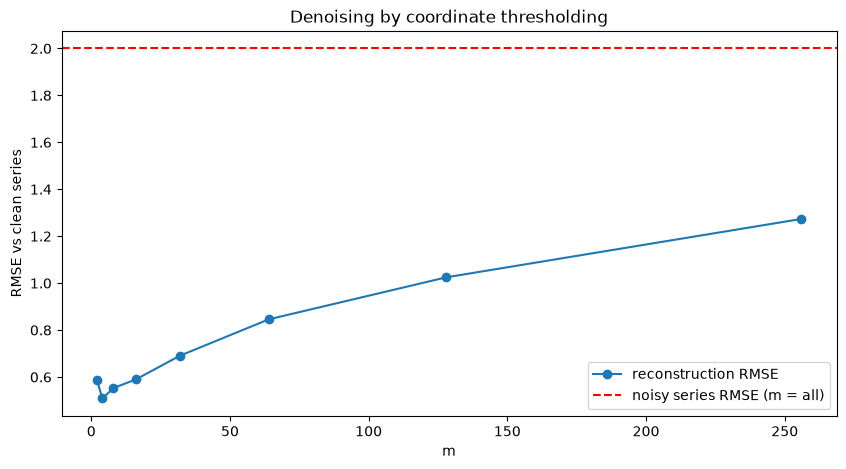

noisy series RMSE           = 1.9999
best m                      = 4, RMSE = 0.5087
std of non-seasonal residual (4.2) = 0.5848


In [15]:
rng = np.random.default_rng(0)
sigma = 2.0
y_noisy = y + sigma * rng.standard_normal(N)

# Subtract the mean before transforming, and add it back after, exactly as
# you did in section 2. If you leave it in, coordinate k=0 is the largest
# of all and spends one of your m slots re-learning the average -- which
# makes the m=2 reconstruction look far worse than it is.

# ========= YOUR CODE STARTS HERE ========= #
mean_noisy = y_noisy.mean()
xn = y_noisy - mean_noisy
cn = dft(xn)

rmses = []
for m in ms_check:
    recon_m = idft(keep_largest(cn, m)).real + mean_noisy
    rmse = np.sqrt(np.mean((recon_m - y) ** 2))
    rmses.append(rmse)

noisy_rmse = np.sqrt(np.mean((y_noisy - y) ** 2))
best_idx = int(np.argmin(rmses))
best_m = ms_check[best_idx]
best_rmse = rmses[best_idx]

plt.figure(figsize=(10, 5))
plt.plot(ms_check, rmses, 'o-', label="reconstruction RMSE")
plt.axhline(noisy_rmse, color='r', linestyle='--', label="noisy series RMSE (m = all)")
plt.xlabel("m"); plt.ylabel("RMSE vs clean series")
plt.title("Denoising by coordinate thresholding"); plt.legend(); plt.show()

print(f"noisy series RMSE           = {noisy_rmse:.4f}")
print(f"best m                      = {best_m}, RMSE = {best_rmse:.4f}")
print(f"std of non-seasonal residual (4.2) = {np.std(residual):.4f}")
# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR ANSWER HERE**

**1-2.** See the plot and numbers above: the curve is clearly U-shaped, with a minimum
RMSE of 0.509 at m=4, well below the noisy series' own RMSE of 2.000.

**3.** The error falls at first because the first coordinates added back (the mean already
removed, then k* and N-k*, then the harmonics) are exactly the true signal coordinates,
they were large before the noise was added, and adding noise of size sigma to each sample
spreads, by Parseval, roughly sigma worth of energy evenly across all N coordinates, each
one gets a small, roughly equal share. So the genuinely large coordinates are barely
perturbed, and recovering them recovers real signal cheaply. The error rises again for
larger m because every additional coordinate beyond the signal's true support is, by
construction, dominated by noise rather than signal, each extra m is just adding back more
of the noise that was spread evenly across all coordinates, which increases error the same
way it would if no filter had been applied at all.

**4.** The best achievable RMSE, 0.509, is close to the standard deviation of the
non-seasonal residual computed in 4.2, 0.585. No choice of m can beat that floor by much,
because that residual variability (long term trend plus irregular month to month weather)
isn't periodic and isn't concentrated in a few Fourier coordinates, that was exactly the
finding of 4.2, so it can't be separated from the added Gaussian noise by magnitude
thresholding. From the transform's point of view, both just look like spread out, low
magnitude coefficients.

**5.** Exactly the same operation as 4.1, keep_largest followed by idft, with the same
code. What changed is only the intent and the yardstick: in 4.1 I measured error against
the clean signal I started from (compression, how much of the original can I throw away
and still be close to it), while here I measure error against a different, clean target
than the one I transformed (denoising, hoping the corruption, not the signal, is what gets
thrown away).

---


---
## 5. Summary

A few sentences each. These are where the defence starts.

1. The DFT is a change of basis. Name three concrete things in this notebook that would
   have failed, or needed extra work, if that basis had been merely a basis rather than an
   **orthonormal** one.
2. Core A found the annual cycle by being told to look for it; Core B found it by looking.
   Which would you use on a signal whose structure you did not already know, and what is
   the cost of that choice?
3. Compression and denoising were the same three lines of code. State the one sentence
   that explains why, and what distinguishes the two in practice.
4. You built $F$ explicitly and then were told never to do that again. When *is* the
   explicit matrix the right thing to have?

---
### **YOUR ANSWER HERE**

**1.** Three concrete things that would have failed if F had been merely a basis and not
orthonormal. First, computing coordinates would require solving a linear system (or
forming F^-1) instead of the single, cheap matrix vector product c = F*x, back to Core A's
normal equation story. Second, idft couldn't stay "one line, no inverse", I'd need the
actual inverse, with all the conditioning risk that implies. Third, Parseval would fail,
so the power spectrum would no longer represent the actual energy of the signal, and the
identity behind section 4 (discarded energy equals reconstruction error, exactly) would
simply be false, coordinate thresholding would become a heuristic with no error guarantee
instead of an exact orthogonal projection.

**2.** On a signal whose structure isn't already known, I'd want Core B's approach:
transform into a fixed, general purpose basis and read the structure off the spectrum,
because there's nothing to tell a Core A style fit to look for. The cost is computational
and interpretive, I have to compute and understand a full N length spectrum instead of
fitting two numbers, and I lose the ability to directly extrapolate a parametric model
beyond the sampled range the way an explicit cos/sin fit can.

**3.** Compression and denoising are the same three lines because both are the identical
operation, keep the few coordinates that carry the most energy in an orthonormal basis,
and discard the rest as an exact projection, applied to two different hopes about where the
important energy sits. In compression I'm keeping the coordinates that dominate the signal
I started with. In denoising I'm hoping those same coordinates still dominate after the
signal has been corrupted, so discarding the rest throws away mostly noise. In practice
they differ in how I choose m: as small as the application can tolerate for compression,
versus tuned to minimize error against a trusted reference for denoising, because too
small or too large an m both increase denoising error, just in opposite directions.

**4.** The explicit matrix is the right tool when N is small enough that O(N^2) storage
and compute are simply affordable (as throughout this notebook, N=1992), when N isn't a
length any fast transform algorithm handles well (not a product of small primes, so no
sub quadratic shortcut exists in the first place), or when I need more from F than just
applying it once, say inspecting individual entries, composing it with other matrices, or
feeding it into further dense linear algebra like SVD or eigendecomposition, where having
the explicit array is the point, not a cost to avoid.

---


---
---
# $\star$ Extension (bonus)

> **Optional. Up to 1 bonus point for the whole lab.** Attempt **at most one** of the three
> extensions &mdash; Extension 3 is below, Extensions 1 and 2 are at the end of Core A. The
> point is for a **finding you can defend**, not for code that ran. Say in your `README`
> which one you chose.

Everything above this line is Core B and is marked in full without this.


---
## $\star$ Extension 3 (bonus): DCT against DFT

The discrete cosine transform uses the orthonormal basis
$$ C_{kn} = \alpha_k \cos\!\Big(\frac{\pi (2n+1) k}{2N}\Big), \qquad
\alpha_0 = \sqrt{1/N},\ \alpha_k = \sqrt{2/N}\ (k \ge 1), $$
and it is the transform inside `jpeg` and most audio codecs. The usual claim is that its
coefficients decay faster than the DFT's. Test that claim on this series &mdash; and be
prepared for it to be only half true.

1. Build $C$ as a matrix, check that it is orthogonal, and check it against
   `scipy.fft.dct(x, norm='ortho')` if you have scipy.
2. For the mean-subtracted series, plot the sorted energies $|c_k|^2$ in both bases on one
   log-scale plot, and report how many coefficients each needs for 98% and for 99.5% of
   the energy. **Which basis wins?**
3. Now repeat on the **residual** from Core B 4.2 &mdash; the series with the annual pair
   removed. **Which basis wins now?**
4. The finding: explain both results. For the first, think about what $N = 12 \times 166$
   did for the DFT, and whether the DCT's cosines can represent a sinusoid of arbitrary
   phase. For the second, plot the residual and look at its two ends: what does the DFT
   assume happens after the last sample, and what does the DCT assume?
5. So: when is the DCT the better basis, and why is that the usual case for images?


C orthogonal: True
scipy not available, skipping cross-check

Full series:
  DFT: 2 coeffs for 98%, 120 for 99.5%
  DCT: 7 coeffs for 98%, 130 for 99.5%


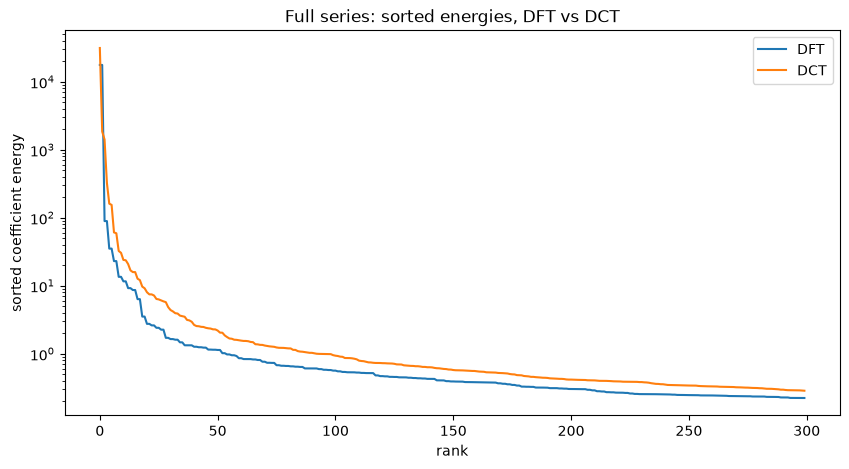


Residual (annual pair removed):
  DFT: 1325 coeffs for 98%, 1652 for 99.5%
  DCT: 1017 coeffs for 98%, 1370 for 99.5%


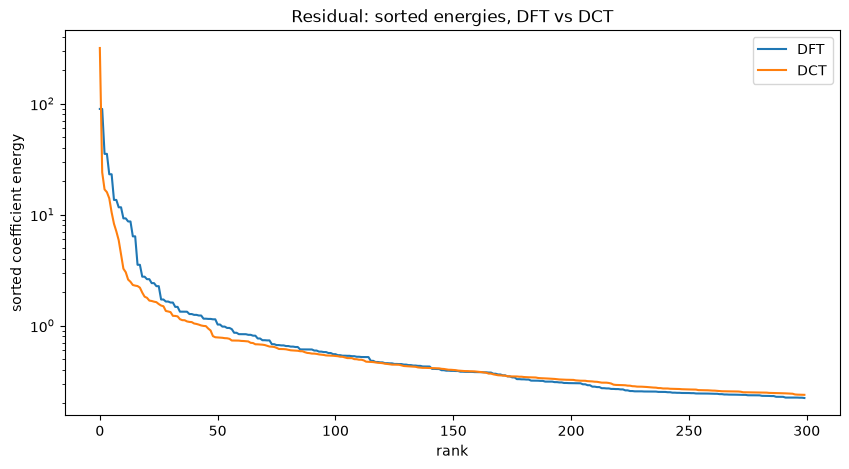


residual[0]  = -1.871
residual[-1] = 1.863


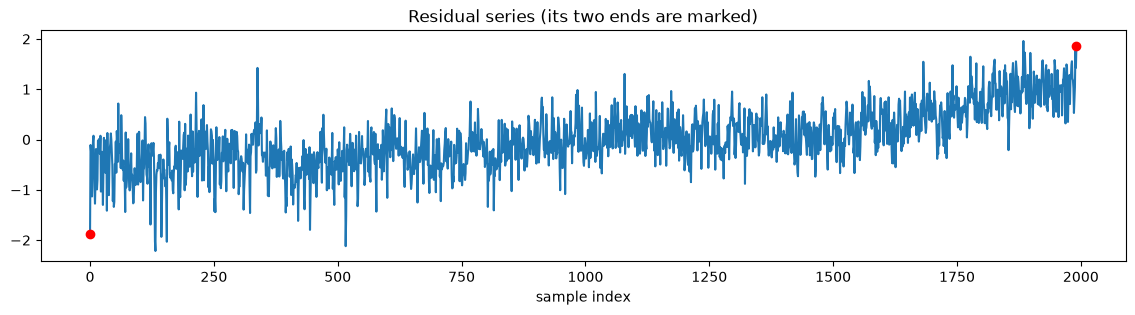

In [16]:
# ========= YOUR CODE STARTS HERE ========= #
def dct_matrix(n: int) -> np.ndarray:
    """Orthonormal DCT-II matrix C with C[k, t] = alpha_k * cos(pi*(2t+1)*k/(2n))."""
    t_idx = np.arange(n)
    k_idx = np.arange(n)
    angle = np.pi * (2 * t_idx[None, :] + 1) * k_idx[:, None] / (2 * n)
    C = np.cos(angle)
    alpha = np.full(n, np.sqrt(2.0 / n))
    alpha[0] = np.sqrt(1.0 / n)
    return alpha[:, None] * C


def coeffs_needed(power_arr, frac):
    total = power_arr.sum()
    sorted_desc = np.sort(power_arr)[::-1]
    cum = np.cumsum(sorted_desc) / total
    return int(np.searchsorted(cum, frac) + 1)


C = dct_matrix(N)
print("C orthogonal:", np.allclose(C @ C.T, np.eye(N), atol=1e-8))

try:
    from scipy.fft import dct as scipy_dct
    c_dct_scipy = scipy_dct(x, type=2, norm="ortho")
    c_dct = C @ x
    print("matches scipy.fft.dct:", np.allclose(c_dct, c_dct_scipy, atol=1e-8))
except ImportError:
    c_dct = C @ x
    print("scipy not available, skipping cross-check")

power_dct = c_dct ** 2

# --- full (mean-subtracted) series: DFT vs DCT ---
m98_dft_full = coeffs_needed(power, 0.98)
m995_dft_full = coeffs_needed(power, 0.995)
m98_dct_full = coeffs_needed(power_dct, 0.98)
m995_dct_full = coeffs_needed(power_dct, 0.995)

print("\nFull series:")
print(f"  DFT: {m98_dft_full} coeffs for 98%, {m995_dft_full} for 99.5%")
print(f"  DCT: {m98_dct_full} coeffs for 98%, {m995_dct_full} for 99.5%")

plt.figure(figsize=(10, 5))
plt.semilogy(np.sort(power)[::-1][:300], label="DFT")
plt.semilogy(np.sort(power_dct)[::-1][:300], label="DCT")
plt.xlabel("rank"); plt.ylabel("sorted coefficient energy")
plt.title("Full series: sorted energies, DFT vs DCT"); plt.legend(); plt.show()

# --- residual (annual pair removed): DFT vs DCT ---
c_dct_res = C @ residual
power_dct_res = c_dct_res ** 2

m98_dft_res = coeffs_needed(power_res, 0.98)
m995_dft_res = coeffs_needed(power_res, 0.995)
m98_dct_res = coeffs_needed(power_dct_res, 0.98)
m995_dct_res = coeffs_needed(power_dct_res, 0.995)

print("\nResidual (annual pair removed):")
print(f"  DFT: {m98_dft_res} coeffs for 98%, {m995_dft_res} for 99.5%")
print(f"  DCT: {m98_dct_res} coeffs for 98%, {m995_dct_res} for 99.5%")

plt.figure(figsize=(10, 5))
plt.semilogy(np.sort(power_res)[::-1][:300], label="DFT")
plt.semilogy(np.sort(power_dct_res)[::-1][:300], label="DCT")
plt.xlabel("rank"); plt.ylabel("sorted coefficient energy")
plt.title("Residual: sorted energies, DFT vs DCT"); plt.legend(); plt.show()

print(f"\nresidual[0]  = {residual[0]:.3f}")
print(f"residual[-1] = {residual[-1]:.3f}")
plt.figure(figsize=(14, 3))
plt.plot(residual)
plt.scatter([0, N - 1], [residual[0], residual[-1]], color='r', zorder=5)
plt.title("Residual series (its two ends are marked)"); plt.xlabel("sample index"); plt.show()
# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR FINDING HERE**

Full (mean-subtracted) series: DFT needs 2 / 120 coordinates for 98%/99.5% of the energy,
DCT needs 7 / 130. DFT wins on the full series.

Residual (annual pair removed): DFT needs 1325 / 1652, DCT needs 1017 / 1370. DCT wins on
the residual.

Why. The full series is dominated by one sinusoid of essentially arbitrary phase (a
specific mix of where in the year January happens to fall), not a pure zero phase cosine.
The DFT represents an arbitrary phase sinusoid in a single complex coefficient, its
magnitude and phase together encode both amplitude and phase shift. The DCT basis
functions are all zero phase cosines, so reproducing a phase shifted sinusoid costs two or
more DCT coefficients working together, since
cos(theta + phi) = cos(phi)*cos(theta) - sin(phi)*sin(theta), and the DCT has no sine terms
to borrow from. That's why DFT is at least as concentrated as DCT on a series whose energy
is dominated by one clean periodic oscillation.

On the residual, the opposite effect dominates: residual[0] = -1.871 and
residual[-1] = 1.863 are clearly not equal. The DFT's implicit model is that the signal is
periodic, it treats sample N-1 as wrapping around to connect back to sample 0. A mismatch
at that seam is a genuine discontinuity from the transform's point of view, and
representing a sharp jump needs many high frequency DFT coefficients, the same Gibbs
phenomenon story as fitting a discontinuity with sines and cosines, so the DFT's
coefficients decay slowly here. The DCT's implicit model is an even, mirrored extension at
both boundaries rather than a periodic wraparound, it never needs to explain a jump at the
seam no matter how different the two endpoints are, so its coefficients keep decaying
quickly even for genuinely non-periodic, merely smooth data.

So: the DCT is the better basis whenever the data is smooth but not naturally periodic,
exactly the situation for a block of a natural image (pixel values at one edge of an 8x8
block have no reason to match the opposite edge), which is why JPEG and most image and
audio codecs use the DCT rather than the DFT, it avoids inventing artificial high
frequency content out of a boundary mismatch that was never really there.

---
